# 3. Exploratory Data Analysis (EDA)

With both datasets cleaned, standardized, and prepared for analysis, we now begin the Exploratory Data Analysis (EDA) phase.  
The goal of EDA is to build a comprehensive understanding of:

- The structure and behavior of each dataset  
- The distribution of key numeric and categorical variables  
- Patterns, trends, and anomalies  
- Relationships between borrower characteristics and loan outcomes  
- Early‑stage borrower behavior (inquiries)  
- Insights that guide feature engineering and modeling decisions  

To maintain clarity and consistency, EDA is divided into two major parts:

- **3A  EDA for the Modeling Dataset (`apps_clean`)**  
- **3B  EDA for the Business Insights Dataset (`inq_clean`)**

This mirrors the structure used in Section 2 and ensures that modeling‑related analysis is kept separate from business‑focused insights.

---

# 3A. EDA  Modeling Dataset (`apps_clean`)

The modeling dataset contains all variables available at application time, cleaned and free of leakage.  
We begin with 10 structured EDA questions:

- **5 statistical questions**  
- **5 business questions (always including the target)**  

---

# **3A.1 Statistical EDA Questions (1–5)**

---

## **3A.Q1  What is the distribution of loan amounts?**

In [58]:
import pandas as pd 
import numpy as np

apps_eda = pd.read_csv('../data/apps_eda.csv')
apps_eda.head()

,requested_amount_usd,repayment_term,monthly_installment_usd,risk_grade_detail,employment_tenure,housing_status,annual_income_usd,income_verification_status,origination_month,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,interest_rate,revolving_utilization,target_default
0,18000.0,60 months,412.61,C3,3 years,own,105000.0,verified,2015-02-01,debt_consolidation,az,6.78,670.0,674.0,7.0,0.0,13.33,89.5,0
1,1000.0,36 months,33.21,C1,1 year,rent,28500.0,not verified,2016-04-01,home_improvement,fl,11.54,690.0,694.0,3.0,1.0,11.99,13.3,0
2,21275.0,36 months,696.42,B4,5 years,mortgage,130000.0,verified,2015-09-01,debt_consolidation,pa,23.08,680.0,684.0,13.0,0.0,10.99,75.7,0
3,35000.0,60 months,869.66,D3,10+ years,mortgage,107000.0,verified,2015-09-01,credit_card,sc,16.30,710.0,714.0,10.0,0.0,16.99,76.5,0
4,17000.0,60 months,427.73,D4,8 years,rent,55000.0,verified,2015-04-01,credit_card,ca,31.27,680.0,684.0,8.0,0.0,17.57,62.5,1


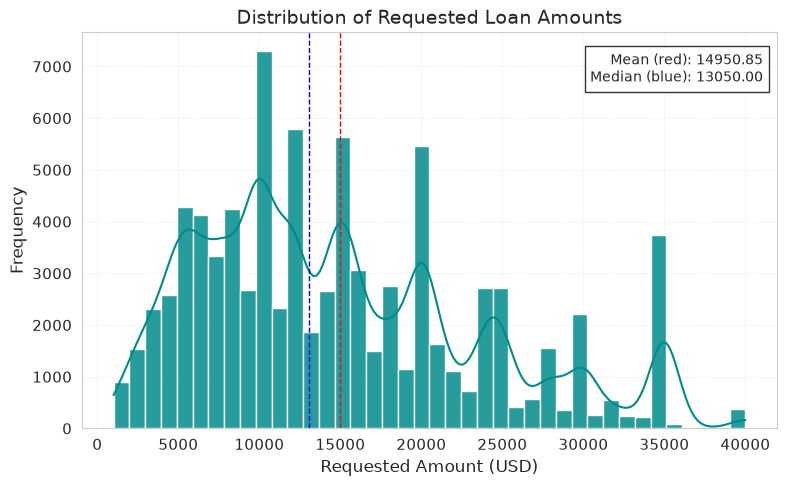

In [59]:
# EDA Setup Cell — Run Once at the Start of Section 3
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

# Calculate mean and median
mean_val = apps_eda['requested_amount_usd'].mean()
median_val = apps_eda['requested_amount_usd'].median()

plt.figure(figsize=(8,5))

# Histogram with a more interesting color (darkcyan)
sns.histplot(
    apps_eda['requested_amount_usd'],
    kde=True,
    bins=40,
    color='darkcyan',
    edgecolor='white',
    alpha=0.85
)

# Softer, lighter gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.35)

# Vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1)
plt.axvline(median_val, color='blue', linestyle='--', linewidth=1)

# Annotation box inside the plot
plt.text(
    0.98, 0.95,
    f"Mean (red): {mean_val:.2f}\nMedian (blue): {median_val:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

# Titles and labels
plt.title("Distribution of Requested Loan Amounts")
plt.xlabel("Requested Amount (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Insight: Distribution of Requested Loan Amounts

The distribution of requested loan amounts shows a clear right‑skewed pattern, indicating that most applicants request moderate loan sizes while a smaller group pushes the upper range with significantly larger requests. This is reflected in the noticeable gap between the **median (~$13,050)** and the **mean (~$14,950)**, where the mean is pulled upward by high‑value outliers.

From a business perspective, this pattern highlights two important dynamics:

- The core of the portfolio is driven by **mid‑sized loan requests**, which likely correspond to common financial needs such as debt consolidation or personal expenses.
- A smaller segment of applicants requests **substantially higher loan amounts**, which can introduce elevated credit risk and may require stricter underwriting or additional verification.

Overall, the loan portfolio is anchored by typical borrowers requesting moderate amounts, but the presence of high‑value outliers introduces meaningful risk considerations that lenders should monitor closely.


## **3A.Q2  How are credit scores distributed?**  
*(Using the average of low + high ranges)*

In [60]:
# Creating the new variable
apps_eda['credit_score_avg'] = (apps_eda['credit_score_low'] + apps_eda['credit_score_high']) / 2

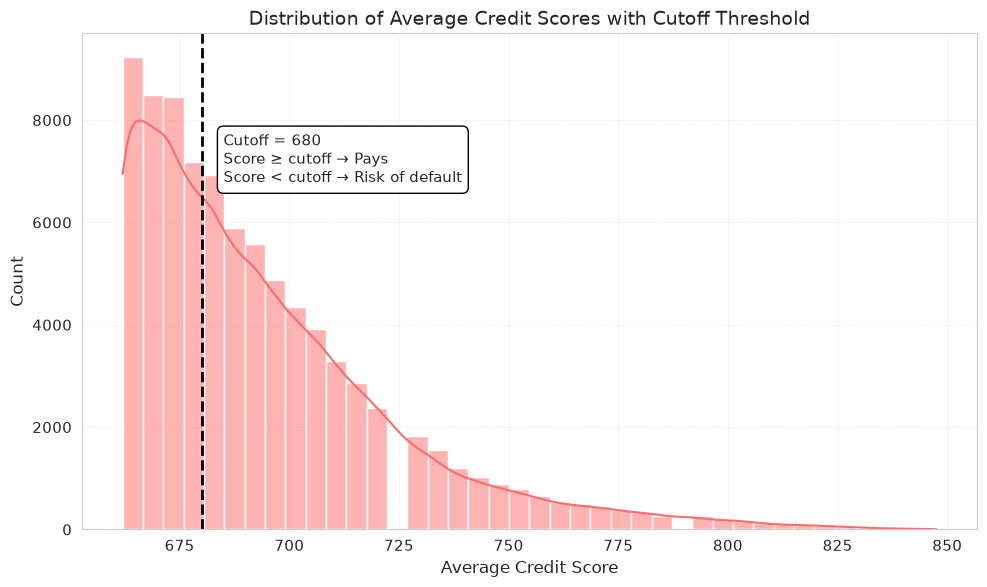

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a cutoff threshold (example: 680)
cutoff = 680

plt.figure(figsize=(10,6))

# Softer, lighter gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.35)

# Histogram with attention-grabbing color
sns.histplot(apps_eda['credit_score_avg'], kde=True, bins=40, color='#FF6B6B')

# Vertical cutoff line
plt.axvline(cutoff, color='black', linestyle='--', linewidth=2)

# Annotation box explaining the rule
plt.text(
    cutoff + 5, 
    plt.ylim()[1] * 0.7,
    f"Cutoff = {cutoff}\nScore ≥ cutoff → Pays\nScore < cutoff → Risk of default",
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)

plt.title("Distribution of Average Credit Scores with Cutoff Threshold", fontsize=14)
plt.xlabel("Average Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Insight  Credit Score Distribution with Operational Cutoff

The distribution of average credit scores is tightly concentrated in the near‑prime range, with most applicants falling between roughly 660 and 700. This clustering indicates that a large portion of the portfolio sits in a borderline credit tier where small score differences may meaningfully shift risk. The left side of the distribution extends further than the right, reflecting a non‑trivial segment of sub‑prime borrowers whose weaker credit profiles align with elevated default likelihood.

Introducing the cutoff threshold provides a clear operational boundary between expected payers and higher‑risk applicants. Borrowers at or above the cutoff fall within the more stable portion of the distribution, while those below it occupy the region where risk accelerates. This visual separation reinforces the practical value of credit score as a screening mechanism and highlights how a single threshold can simplify decision‑making while still capturing meaningful variation in borrower quality.


## **3A.Q3  What is the correlation structure among numeric variables?**

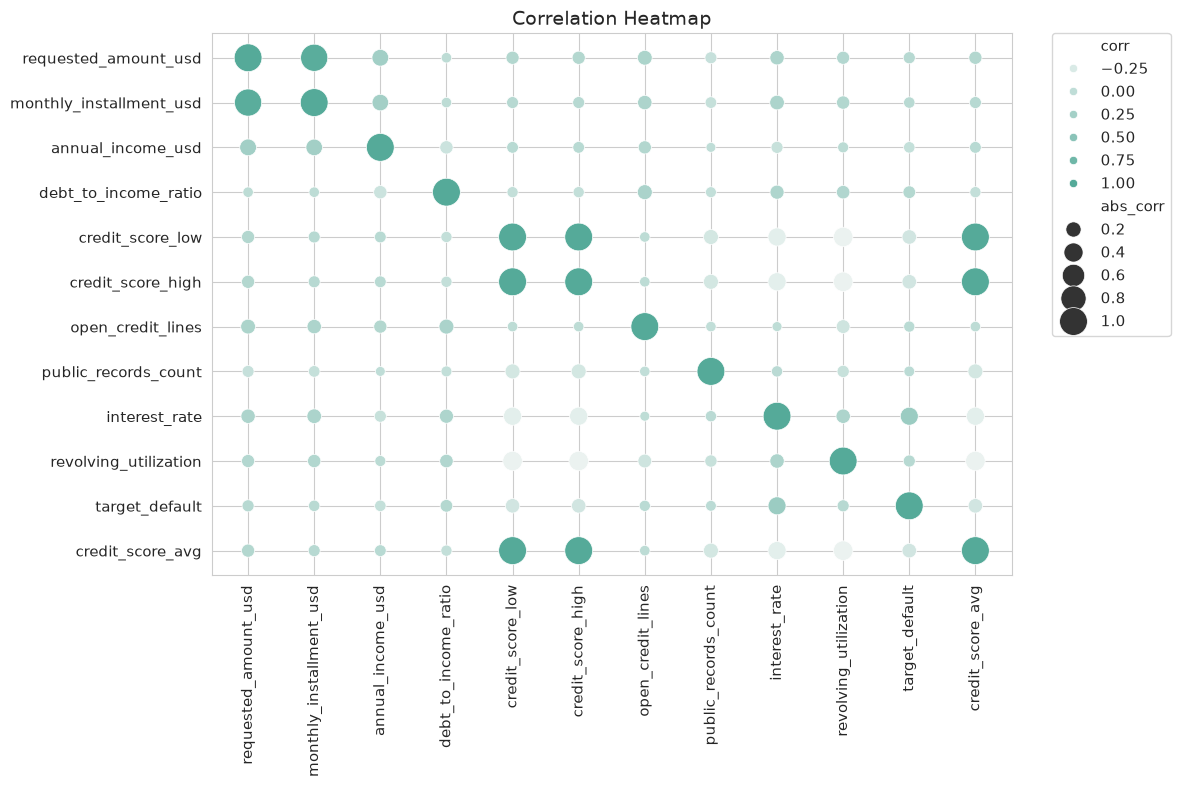

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Recalculate numeric columns directly from the dataframe to ensure completeness
numeric_cols = apps_eda.select_dtypes(include=['int64','float64']).columns.tolist()


# Compute correlation matrix
corr = apps_eda[numeric_cols].corr()

# Melt for scatter-style heatmap
corr_melt = corr.reset_index().melt(id_vars='index')
corr_melt.columns = ['var1', 'var2', 'corr']
corr_melt['abs_corr'] = corr_melt['corr'].abs()

# Your custom colormap
cmap = sns.color_palette("light:#5A9", as_cmap=True)

plt.figure(figsize=(12, 8))

# Create the scatter heatmap
ax = sns.scatterplot(
    data=corr_melt,
    x="var1",
    y="var2",
    hue="corr",
    size="abs_corr",
    sizes=(50, 400),
    palette=cmap,
    edgecolor="white",
    linewidth=0.5,
    legend="brief"
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.title("Correlation Heatmap", fontsize=14)

# Move legend OUTSIDE the plot
plt.legend(
    bbox_to_anchor=(1.05, 1),   # move legend to the right
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


### Insight  Correlation Structure from a Risk‑Management Perspective

From a risk‑management standpoint, the correlation matrix highlights several structural relationships that influence both underwriting quality and portfolio exposure. The strong correlation between requested loan amount and monthly installment reflects predictable financial mechanics, but it also signals that any mispricing or misclassification of high‑balance borrowers can disproportionately affect loss severity. Similarly, the tight alignment between credit score low and credit score high confirms that the score ranges are stable and reliable, reinforcing credit score as a foundational risk indicator.

The negative correlation between interest rate and credit score measures is consistent with risk‑based pricing, but it also underscores a key vulnerability: borrowers with weaker credit profiles are simultaneously exposed to higher borrowing costs, which may amplify repayment stress and increase default probability. Debt‑to‑income ratio’s moderate correlation with revolving utilization and interest rate suggests that financially strained borrowers tend to accumulate higher utilization and face more expensive credit terms—an early warning pattern for deteriorating credit health.

Variables such as public records count and open credit lines show limited correlation with the rest of the feature set, indicating that they capture independent dimensions of borrower behavior. These low‑correlation features can be especially valuable in risk modeling because they introduce orthogonal signals that help identify hidden pockets of risk not explained by income, loan size, or credit score alone.

Overall, the correlation structure suggests a portfolio where a few variables are tightly linked through pricing and loan mechanics, while others provide distinct behavioral signals. For risk managers, this combination supports a diversified feature set that can improve early‑warning detection, strengthen underwriting decisions, and reduce blind spots in credit‑risk assessment.


## **3A.Q4  How does DTI vary across borrowers?**

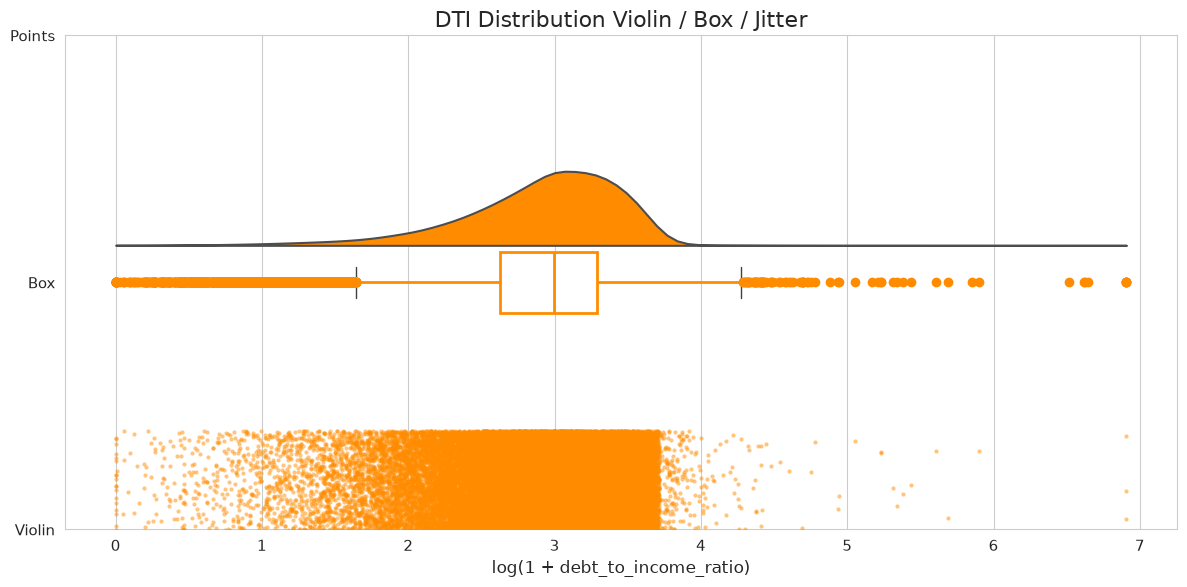

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt

# Ensure log-transformed DTI exists
apps_eda['log_dti'] = np.log1p(apps_eda['debt_to_income_ratio'])

plt.figure(figsize=(12, 6))

# --- SINGLE COLOR THEME ---
orange = "#FF8C00"   # deep orange, looks great in plots

# 1. VIOLIN (shifted upward)
pt.half_violinplot(
    x=apps_eda['log_dti'],
    y=[1]*len(apps_eda),
    palette=[orange],
    bw=.2,
    cut=0,
    scale='area',
    width=.6,
    inner=None,
    orient='h'
)

# 2. BOX PLOT (centered)
sns.boxplot(
    x=apps_eda['log_dti'],
    y=[0]*len(apps_eda),
    width=0.25,
    showcaps=True,
    boxprops={'facecolor':'none', 'edgecolor':orange, 'linewidth':2},
    whiskerprops={'linewidth':2, 'color':orange},
    medianprops={'color':orange, 'linewidth':2},
    flierprops={'marker':'o', 'markerfacecolor':orange, 'markeredgecolor':orange},
    showfliers=True,
    orient='h'
)

# 3. JITTER POINTS (shifted downward)
sns.stripplot(
    x=apps_eda['log_dti'],
    y=[-1]*len(apps_eda),
    color=orange,
    size=3,
    jitter=0.4,
    alpha=0.5,
    orient='h'
)

plt.yticks([1, 0, -1], ["Violin", "Box", "Points"])
plt.title("DTI Distribution Violin / Box / Jitter", fontsize=16)
plt.xlabel("log(1 + debt_to_income_ratio)")
plt.tight_layout()
plt.show()


# Insight: Debt-to-Income Distribution (Log-Transformed)

The distribution shows a concentrated cluster of borrowers with relatively low DTI levels and a long right tail of higher-DTI individuals. From a risk-management perspective, this tail represents the primary source of credit exposure. While the median borrower appears stable, the presence of numerous high-DTI outliers indicates a segment with elevated leverage and increased vulnerability to income or interest-rate shocks. These borrowers are more likely to default under stress conditions and should be prioritized for enhanced monitoring, affordability checks, and early-warning triggers.
